Import Library

In [8]:
# ============================================
# CELL 1: Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries loaded!")

✅ Libraries loaded!


Load Dataset

In [10]:
# ============================================
# CELL 2: Load Data
# ============================================
df = pd.read_csv('../data/online_retail.csv', encoding='latin-1')

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


Data Overview

In [12]:
# ============================================
# CELL 3: Data Quality Check
# ============================================
print("=== DATA INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print(f"\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== DATA INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None

=== MISSING VALUES ===
             Missing  Percentage
Description     1454        0.27
CustomerID    135080       24.93

=== DUPLICATES ===
Duplicate rows: 5268


Data Cleaning

In [13]:
# ============================================
# CELL 4: Data Cleaning
# ============================================
df_clean = df.copy()

# Hapus baris tanpa CustomerID (tidak bisa dianalisis)
df_clean = df_clean.dropna(subset=['CustomerID'])

# Hapus duplikat
df_clean = df_clean.drop_duplicates()

# Hapus transaksi yang di-cancel (InvoiceNo mulai dengan 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Hapus Quantity & UnitPrice yang negatif/nol
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Tambah kolom Revenue & parse tanggal
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Month_Name'] = df_clean['InvoiceDate'].dt.strftime('%b')
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

print(f"✅ Cleaning selesai!")
print(f"Before: {df.shape[0]} rows → After: {df_clean.shape[0]} rows")
print(f"Revenue column sample:\n{df_clean['Revenue'].describe()}")

✅ Cleaning selesai!
Before: 541909 rows → After: 392692 rows
Revenue column sample:
count   392692.00
mean        22.63
std        311.10
min          0.00
25%          4.95
50%         12.45
75%         19.80
max     168469.60
Name: Revenue, dtype: float64


Summary KPI

In [14]:
# ============================================
# CELL 5: Sales Performance - KPI Summary
# ============================================
total_revenue     = df_clean['Revenue'].sum()
total_orders      = df_clean['InvoiceNo'].nunique()
total_customers   = df_clean['CustomerID'].nunique()
total_products    = df_clean['StockCode'].nunique()
avg_order_value   = total_revenue / total_orders

print("=" * 40)
print("       📊 BUSINESS KPI SUMMARY")
print("=" * 40)
print(f"💰 Total Revenue     : £{total_revenue:,.2f}")
print(f"🧾 Total Orders      : {total_orders:,}")
print(f"👥 Total Customers   : {total_customers:,}")
print(f"📦 Total Products    : {total_products:,}")
print(f"🛒 Avg Order Value   : £{avg_order_value:,.2f}")
print("=" * 40)

       📊 BUSINESS KPI SUMMARY
💰 Total Revenue     : £8,887,208.89
🧾 Total Orders      : 18,532
👥 Total Customers   : 4,338
📦 Total Products    : 3,665
🛒 Avg Order Value   : £479.56


Monthly Revenue Trend

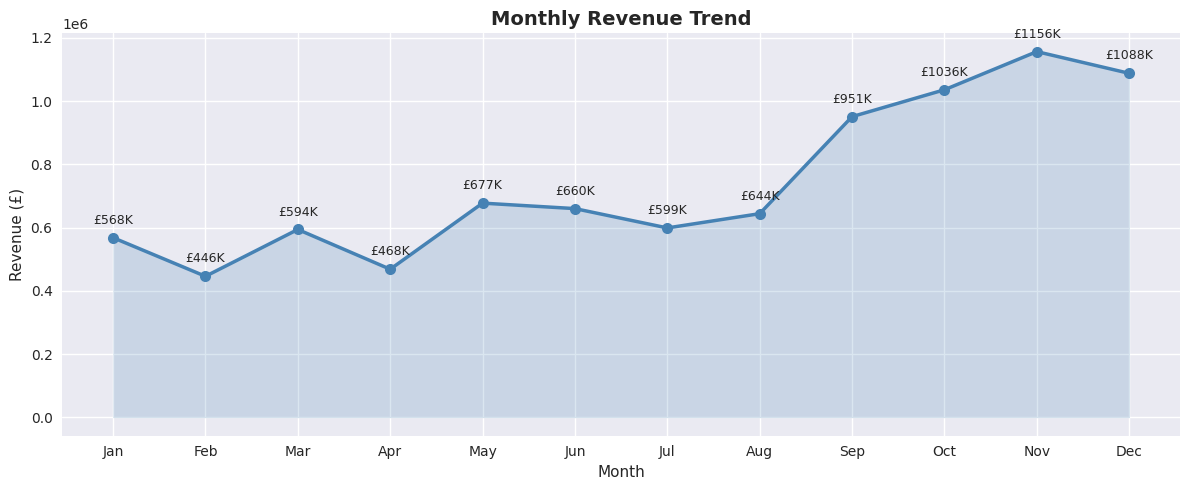

✅ Chart saved!


In [15]:
# ============================================
# CELL 6: Monthly Revenue Trend
# ============================================
monthly_revenue = df_clean.groupby(['Month', 'Month_Name'])['Revenue'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('Month')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue['Month_Name'], monthly_revenue['Revenue'], 
        marker='o', linewidth=2.5, markersize=8, color='steelblue')
ax.fill_between(range(len(monthly_revenue)), monthly_revenue['Revenue'], alpha=0.2, color='steelblue')

# Annotate tiap titik
for i, row in monthly_revenue.iterrows():
    ax.annotate(f"£{row['Revenue']/1000:.0f}K", 
                xy=(row['Month']-1, row['Revenue']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.set_xticks(range(len(monthly_revenue)))
ax.set_xticklabels(monthly_revenue['Month_Name'])

plt.tight_layout()
plt.savefig('../images/monthly_revenue.png', dpi=150)
plt.show()
print("✅ Chart saved!")

Revenue Growth Rate MoM

In [16]:
# ============================================
# CELL 7: Revenue Growth Rate MoM
# ============================================
monthly_revenue['Growth_Rate'] = monthly_revenue['Revenue'].pct_change() * 100

print("📈 Month-over-Month Revenue Growth:")
print("-" * 35)
for _, row in monthly_revenue.iterrows():
    growth = row['Growth_Rate']
    if pd.isna(growth):
        print(f"  {row['Month_Name']:>4}: (baseline)")
    else:
        arrow = "🔺" if growth > 0 else "🔻"
        print(f"  {row['Month_Name']:>4}: {arrow} {growth:+.1f}%")

📈 Month-over-Month Revenue Growth:
-----------------------------------
   Jan: (baseline)
   Feb: 🔻 -21.5%
   Mar: 🔺 +33.2%
   Apr: 🔻 -21.2%
   May: 🔺 +44.6%
   Jun: 🔻 -2.6%
   Jul: 🔻 -9.3%
   Aug: 🔺 +7.5%
   Sep: 🔺 +47.6%
   Oct: 🔺 +8.9%
   Nov: 🔺 +11.6%
   Dec: 🔻 -5.9%


Top 10 Products Analysis

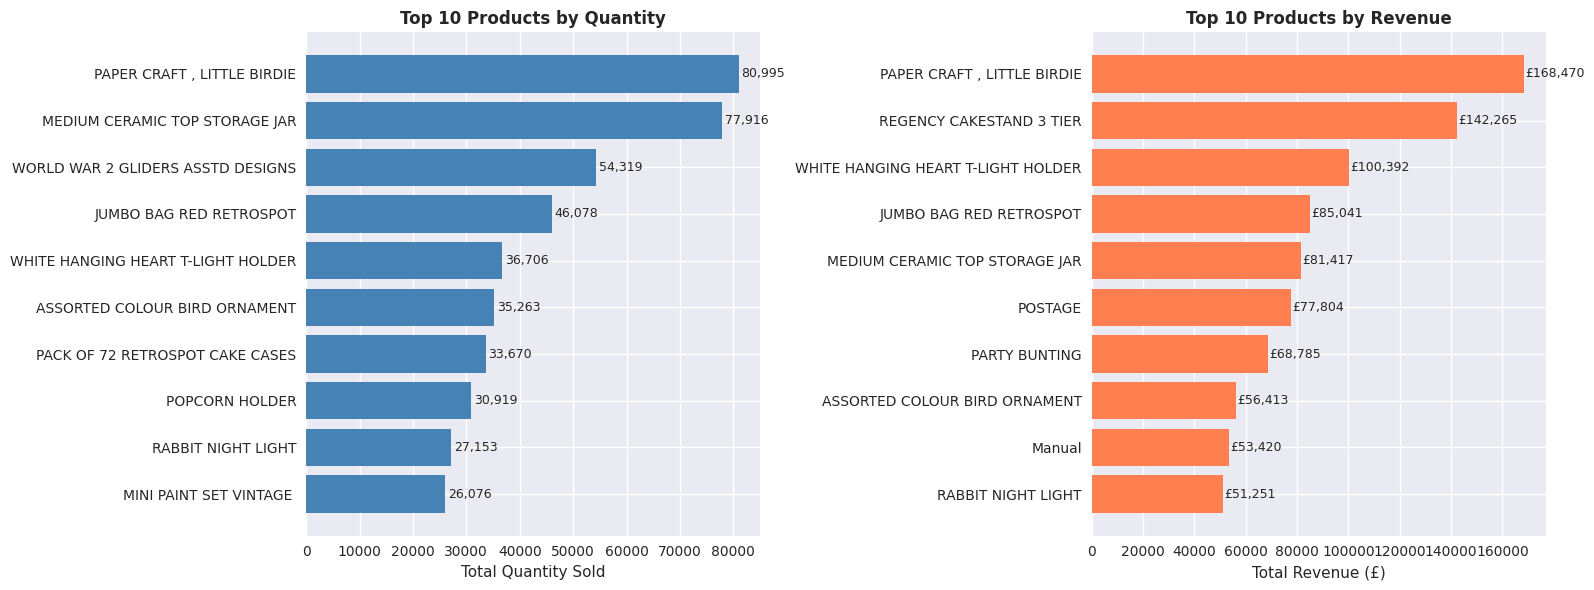

✅ Chart saved!


In [17]:
# ============================================
# CELL 8: Top 10 Products Analysis
# ============================================
# By Quantity
top_qty = (df_clean.groupby('Description')['Quantity']
           .sum().sort_values(ascending=False).head(10).reset_index())

# By Revenue
top_rev = (df_clean.groupby('Description')['Revenue']
           .sum().sort_values(ascending=False).head(10).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Quantity
axes[0].barh(top_qty['Description'], top_qty['Quantity'], color='steelblue')
axes[0].set_title('Top 10 Products by Quantity', fontweight='bold')
axes[0].set_xlabel('Total Quantity Sold')
axes[0].invert_yaxis()
for i, v in enumerate(top_qty['Quantity']):
    axes[0].text(v + 500, i, f'{v:,}', va='center', fontsize=9)

# Plot Revenue
axes[1].barh(top_rev['Description'], top_rev['Revenue'], color='coral')
axes[1].set_title('Top 10 Products by Revenue', fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].invert_yaxis()
for i, v in enumerate(top_rev['Revenue']):
    axes[1].text(v + 500, i, f'£{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/top_products.png', dpi=150)
plt.show()
print("✅ Chart saved!")

Slow Moving Products

In [18]:
# ============================================
# CELL 9: Slow Moving Products
# ============================================
slow_products = (df_clean.groupby('Description')['Quantity']
                 .sum().sort_values(ascending=True).head(10).reset_index())

print("⚠️ Top 10 Produk Paling Jarang Terjual:")
print("-" * 45)
for _, row in slow_products.iterrows():
    print(f"  {row['Description'][:40]:<40} → {row['Quantity']:,} pcs")

⚠️ Top 10 Produk Paling Jarang Terjual:
---------------------------------------------
  CRACKED GLAZE EARRINGS RED               → 1 pcs
  CRACKED GLAZE EARRINGS BROWN             → 1 pcs
  WHITE ROSEBUD  PEARL EARRINGS            → 1 pcs
  MIDNIGHT BLUE CRYSTAL DROP EARRINGS      → 1 pcs
  BLUE PADDED SOFT MOBILE                  → 1 pcs
  BLUE NEW BAROQUE FLOCK CANDLESTICK       → 1 pcs
  BLUE LEAVES AND BEADS PHONE CHARM        → 1 pcs
  NEW BAROQUE B'FLY NECKLACE PINK          → 1 pcs
  BLUE/GREEN SHELL NECKLACE W PENDANT      → 1 pcs
  BLUE/NAT SHELL NECKLACE W PENDANT        → 1 pcs


Customer Analysis

In [19]:
# ============================================
# CELL 10: Customer Analysis
# ============================================
customer_df = df_clean.groupby('CustomerID').agg(
    Total_Orders    = ('InvoiceNo', 'nunique'),
    Total_Revenue   = ('Revenue', 'sum'),
    Total_Items     = ('Quantity', 'sum')
).reset_index()

customer_df['Avg_Order_Value'] = customer_df['Total_Revenue'] / customer_df['Total_Orders']

# KPI
avg_order_value   = customer_df['Avg_Order_Value'].mean()
repeat_customers  = customer_df[customer_df['Total_Orders'] > 1].shape[0]
repeat_rate       = repeat_customers / customer_df.shape[0] * 100

print("=" * 40)
print("       👥 CUSTOMER ANALYSIS")
print("=" * 40)
print(f"🛒 Avg Order Value      : £{avg_order_value:,.2f}")
print(f"🔁 Repeat Customer Rate : {repeat_rate:.1f}%")
print(f"👥 Total Customers      : {customer_df.shape[0]:,}")
print("=" * 40)

# Top 10 Most Loyal (by orders)
print("\n🏆 Top 10 Most Loyal Customers (by orders):")
print(customer_df.sort_values('Total_Orders', ascending=False).head(10)
      [['CustomerID','Total_Orders','Total_Revenue']].to_string(index=False))

# Top 10 Most Profitable (by revenue)
print("\n💰 Top 10 Most Profitable Customers:")
print(customer_df.sort_values('Total_Revenue', ascending=False).head(10)
      [['CustomerID','Total_Orders','Total_Revenue']].to_string(index=False))

       👥 CUSTOMER ANALYSIS
🛒 Avg Order Value      : £417.65
🔁 Repeat Customer Rate : 65.6%
👥 Total Customers      : 4,338

🏆 Top 10 Most Loyal Customers (by orders):
 CustomerID  Total_Orders  Total_Revenue
   12748.00           209       33053.19
   14911.00           201      143711.17
   17841.00           124       40519.84
   13089.00            97       58762.08
   14606.00            93       12076.15
   15311.00            91       60632.75
   12971.00            86       11189.91
   14646.00            73      280206.02
   16029.00            63       80850.84
   13408.00            62       28117.04

💰 Top 10 Most Profitable Customers:
 CustomerID  Total_Orders  Total_Revenue
   14646.00            73      280206.02
   18102.00            60      259657.30
   17450.00            46      194390.79
   16446.00             2      168472.50
   14911.00           201      143711.17
   12415.00            21      124914.53
   14156.00            55      117210.08
   17511.00       

 Time-Based Analysis

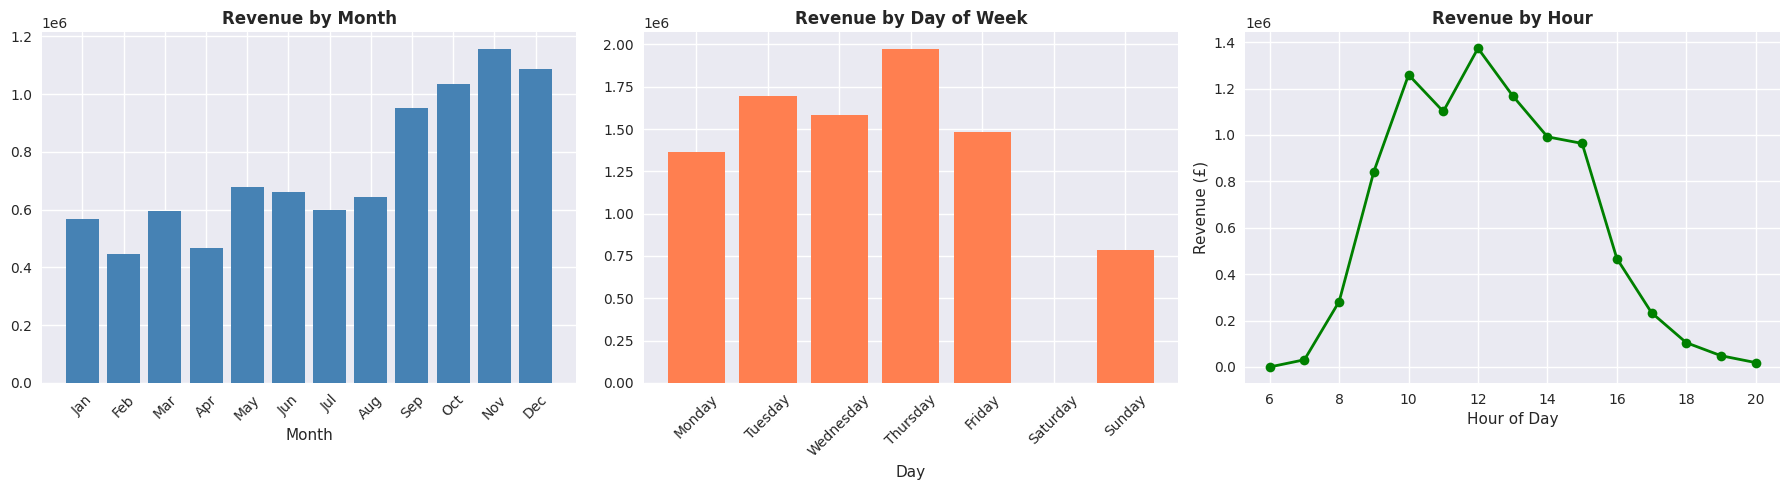

✅ Chart saved!


In [20]:
# ============================================
# CELL 11: Time-Based Analysis
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. By Month
monthly = df_clean.groupby('Month_Name')['Revenue'].sum()
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = monthly.reindex([m for m in month_order if m in monthly.index])
axes[0].bar(monthly.index, monthly.values, color='steelblue')
axes[0].set_title('Revenue by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].tick_params(axis='x', rotation=45)

# 2. By Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df_clean.groupby('DayOfWeek')['Revenue'].sum().reindex(day_order)
axes[1].bar(daily.index, daily.values, color='coral')
axes[1].set_title('Revenue by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].tick_params(axis='x', rotation=45)

# 3. By Hour
hourly = df_clean.groupby('Hour')['Revenue'].sum()
axes[2].plot(hourly.index, hourly.values, marker='o', color='green', linewidth=2)
axes[2].set_title('Revenue by Hour', fontweight='bold')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.savefig('../images/time_analysis.png', dpi=150)
plt.show()
print("✅ Chart saved!")

Country Analysis

🌍 Top 10 Countries by Revenue:
-----------------------------------
  United Kingdom            £7,285,024.64  (82.0%)
  Netherlands               £  285,446.34  (3.2%)
  EIRE                      £  265,262.46  (3.0%)
  Germany                   £  228,678.40  (2.6%)
  France                    £  208,934.31  (2.4%)
  Australia                 £  138,453.81  (1.6%)
  Spain                     £   61,558.56  (0.7%)
  Switzerland               £   56,443.95  (0.6%)
  Belgium                   £   41,196.34  (0.5%)
  Sweden                    £   38,367.83  (0.4%)


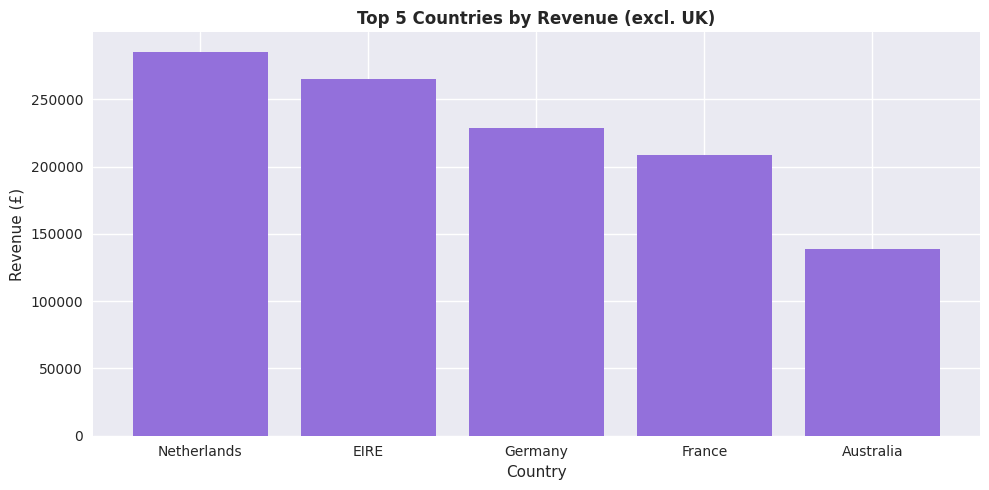

✅ Chart saved!


In [21]:
# ============================================
# CELL 12: Country Analysis
# ============================================
country_rev = (df_clean.groupby('Country')['Revenue']
               .sum().sort_values(ascending=False).reset_index())

print("🌍 Top 10 Countries by Revenue:")
print("-" * 35)
for _, row in country_rev.head(10).iterrows():
    pct = row['Revenue'] / country_rev['Revenue'].sum() * 100
    print(f"  {row['Country']:<25} £{row['Revenue']:>12,.2f}  ({pct:.1f}%)")

# Bar chart (exclude UK karena dominan, supaya chart lebih readable)
top5_excl_uk = country_rev[country_rev['Country'] != 'United Kingdom'].head(5)

plt.figure(figsize=(10, 5))
plt.bar(top5_excl_uk['Country'], top5_excl_uk['Revenue'], color='mediumpurple')
plt.title('Top 5 Countries by Revenue (excl. UK)', fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../images/country_analysis.png', dpi=150)
plt.show()
print("✅ Chart saved!")

RFM Analysis

In [22]:
# ============================================
# CELL 13: RFM Analysis
# ============================================
import datetime

# Tentukan reference date (1 hari setelah transaksi terakhir)
reference_date = df_clean['InvoiceDate'].max() + datetime.timedelta(days=1)
print(f"Reference Date: {reference_date.date()}")

# Hitung RFM per customer
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(f"\n📊 RFM Sample:")
print(rfm.head(10).to_string(index=False))
print(f"\n📈 RFM Stats:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

Reference Date: 2011-12-10

📊 RFM Sample:
 CustomerID  Recency  Frequency  Monetary
   12346.00      326          1  77183.60
   12347.00        2          7   4310.00
   12348.00       75          4   1797.24
   12349.00       19          1   1757.55
   12350.00      310          1    334.40
   12352.00       36          8   2506.04
   12353.00      204          1     89.00
   12354.00      232          1   1079.40
   12355.00      214          1    459.40
   12356.00       23          3   2811.43

📈 RFM Stats:
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean     92.54       4.27   2048.69
std     100.01       7.70   8985.23
min       1.00       1.00      3.75
25%      18.00       1.00    306.48
50%      51.00       2.00    668.57
75%     142.00       5.00   1660.60
max     374.00     209.00 280206.02


RFM Scoring

In [23]:
# ============================================
# CELL 14: RFM Scoring
# ============================================
# Score 4 = terbaik, 1 = terburuk
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1])  # Recency: makin kecil makin baik
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

print("✅ RFM Scoring selesai!")
print(rfm[['CustomerID','Recency','Frequency','Monetary','RFM_Score','RFM_Total']].head(10).to_string(index=False))

✅ RFM Scoring selesai!
 CustomerID  Recency  Frequency  Monetary RFM_Score  RFM_Total
   12346.00      326          1  77183.60       114          6
   12347.00        2          7   4310.00       444         12
   12348.00       75          4   1797.24       234          9
   12349.00       19          1   1757.55       314          8
   12350.00      310          1    334.40       112          4
   12352.00       36          8   2506.04       344         11
   12353.00      204          1     89.00       111          3
   12354.00      232          1   1079.40       113          5
   12355.00      214          1    459.40       112          4
   12356.00       23          3   2811.43       334         10


Customer Segmentation

In [24]:
# ============================================
# CELL 15: Customer Segmentation
# ============================================
def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r == 1 and f >= 3:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Need Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Summary per segment
segment_summary = rfm.groupby('Segment').agg(
    Count    = ('CustomerID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean')
).round(2).sort_values('Count', ascending=False)

print("🎯 Customer Segment Summary:")
print(segment_summary.to_string())

🎯 Customer Segment Summary:
                    Count  Avg_Recency  Avg_Frequency  Avg_Monetary
Segment                                                            
Lost Customers       1504       186.57           1.25        508.82
Loyal Customers      1034        22.63           5.22       2088.74
Champions             489         7.42          15.53       9047.80
At Risk               449       106.22           4.68       2128.69
Potential Loyalist    349        33.45           1.31        311.82
New Customers         234         9.99           1.56       1226.13
Need Attention        187        66.53           2.49        803.96
Cant Lose Them         92       213.53           2.92        390.85


RFM Visualization

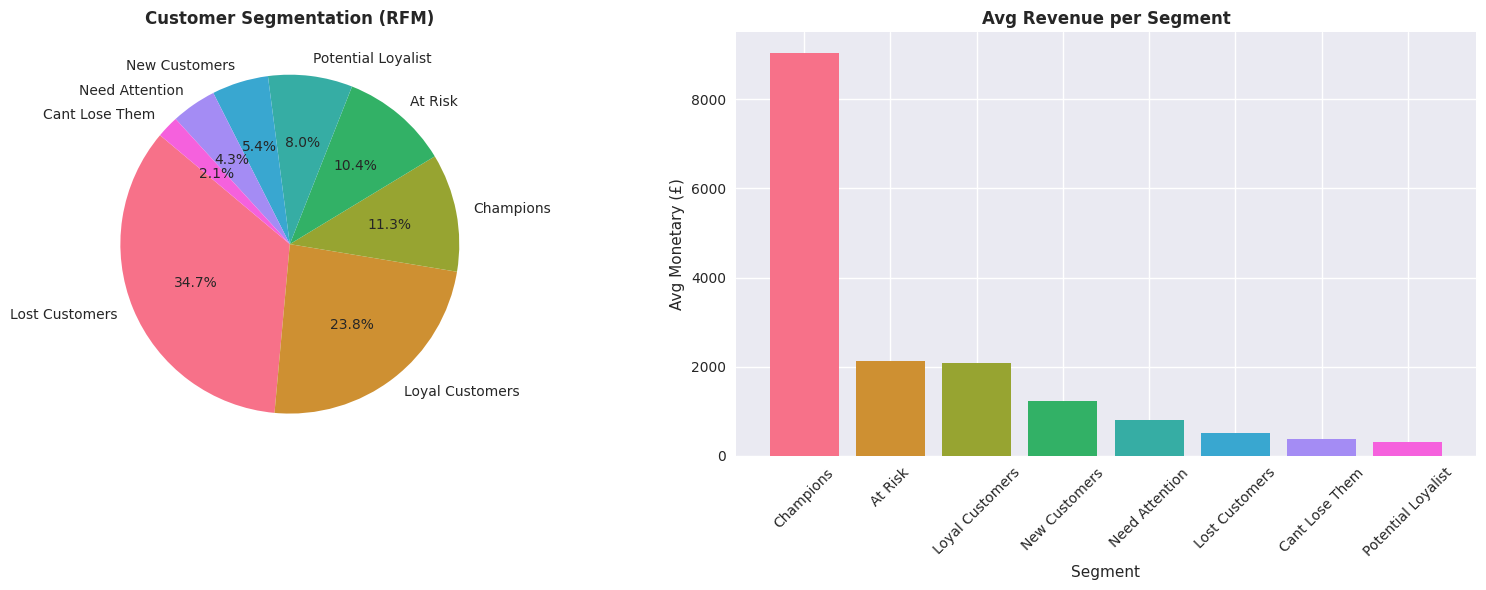

✅ RFM Chart saved!


In [25]:
# ============================================
# CELL 16: RFM Visualization
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Pie chart segment
segment_count = rfm['Segment'].value_counts()
axes[0].pie(segment_count.values, labels=segment_count.index, 
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('husl', len(segment_count)))
axes[0].set_title('Customer Segmentation (RFM)', fontweight='bold')

# 2. Bar chart avg monetary per segment
seg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
axes[1].bar(seg_monetary.index, seg_monetary.values, color=sns.color_palette('husl', len(seg_monetary)))
axes[1].set_title('Avg Revenue per Segment', fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg Monetary (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../images/rfm_analysis.png', dpi=150)
plt.show()
print("✅ RFM Chart saved!")

Collect All Insights

In [26]:
# ============================================
# CELL 17: Collect All Insights
# ============================================

# Ambil data untuk README
peak_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmax(), 'Month_Name']
peak_day   = daily.idxmax()
peak_hour  = hourly.idxmax()

top1_product_qty = top_qty.iloc[0]['Description']
top1_product_rev = top_rev.iloc[0]['Description']

top_country = country_rev.iloc[0]['Country']
top_country2 = country_rev[country_rev['Country'] != 'United Kingdom'].iloc[0]['Country']

champions_pct = (rfm[rfm['Segment'] == 'Champions'].shape[0] / rfm.shape[0] * 100)
at_risk_pct   = (rfm[rfm['Segment'] == 'At Risk'].shape[0] / rfm.shape[0] * 100)

print("=" * 45)
print("📋 KEY INSIGHTS SUMMARY")
print("=" * 45)
print(f"💰 Total Revenue        : £{total_revenue:,.2f}")
print(f"🧾 Total Orders         : {total_orders:,}")
print(f"👥 Total Customers      : {total_customers:,}")
print(f"🛒 Avg Order Value      : £{avg_order_value:,.2f}")
print(f"🔁 Repeat Customer Rate : {repeat_rate:.1f}%")
print(f"📅 Peak Month           : {peak_month}")
print(f"📆 Peak Day             : {peak_day}")
print(f"⏰ Peak Hour            : {peak_hour}:00")
print(f"📦 Top Product (Qty)    : {top1_product_qty}")
print(f"💵 Top Product (Rev)    : {top1_product_rev}")
print(f"🌍 Top Country          : {top_country}")
print(f"🌏 Top Non-UK Country   : {top_country2}")
print(f"🏆 Champions %          : {champions_pct:.1f}%")
print(f"⚠️  At Risk %            : {at_risk_pct:.1f}%")

📋 KEY INSIGHTS SUMMARY
💰 Total Revenue        : £8,887,208.89
🧾 Total Orders         : 18,532
👥 Total Customers      : 4,338
🛒 Avg Order Value      : £417.65
🔁 Repeat Customer Rate : 65.6%
📅 Peak Month           : Nov
📆 Peak Day             : Thursday
⏰ Peak Hour            : 12:00
📦 Top Product (Qty)    : PAPER CRAFT , LITTLE BIRDIE
💵 Top Product (Rev)    : PAPER CRAFT , LITTLE BIRDIE
🌍 Top Country          : United Kingdom
🌏 Top Non-UK Country   : Netherlands
🏆 Champions %          : 11.3%
⚠️  At Risk %            : 10.4%
